# 04 - Estrategia de quiniela y resultados de la simulación

Lee los outputs del pipeline:
- `outputs/picks/quiniela_*.csv` (4 perfiles de riesgo)
- `outputs/simulations/*` (probabilidades agregadas Monte-Carlo)

Visualiza el bracket esperado, compara picks entre perfiles, y muestra los favoritos al título.

**Prerequisito**: haber corrido `export_quiniela_sheet.py` y `simulate_tournament.py`.

In [1]:
import sys
from pathlib import Path

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

OUTPUTS = ROOT / 'outputs'
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)

## Carga de las 4 quinielas

In [2]:
PROFILES = ['safe', 'balanced', 'aggressive', 'contrarian']
sheets = {p: pd.read_csv(OUTPUTS / 'picks' / f'quiniela_{p}.csv') for p in PROFILES}

for p, df in sheets.items():
    print(f'{p:12s}: {len(df)} picks  | distribución: {df["pick"].value_counts().to_dict()}  | confianza media: {df["confidence"].mean():.3f}')

safe        : 72 picks  | distribución: {'A': 37, 'H': 35}  | confianza media: 0.484
balanced    : 72 picks  | distribución: {'H': 31, 'D': 22, 'A': 19}  | confianza media: 0.444
aggressive  : 72 picks  | distribución: {'H': 50, 'A': 21, 'D': 1}  | confianza media: 0.411
contrarian  : 72 picks  | distribución: {'A': 39, 'H': 33}  | confianza media: 0.265


## Comparación de picks por partido entre los 4 perfiles

Muestra los partidos donde los perfiles **difieren** — son los que tienen mayor valor estratégico.

In [3]:
merge_cols = ['team_a', 'team_b']
base = sheets['balanced'][merge_cols + ['p_home', 'p_draw', 'p_away']].copy()
for p in PROFILES:
    base[f'pick_{p}'] = sheets[p]['pick'].values

different = base[
    (base['pick_safe'] != base['pick_balanced'])
    | (base['pick_balanced'] != base['pick_aggressive'])
    | (base['pick_aggressive'] != base['pick_contrarian'])
]
print(f'Partidos donde difieren los perfiles: {len(different)} / {len(base)}')
print()
print(different.head(20).to_string(index=False))

Partidos donde difieren los perfiles: 72 / 72

       team_a             team_b   p_home   p_draw   p_away pick_safe pick_balanced pick_aggressive pick_contrarian
       Mexico       South Africa 0.525903 0.302229 0.171869         H             H               H               A
  South Korea            Czechia 0.592870 0.234542 0.172588         H             H               H               A
       Canada Bosnia-Herzegovina 0.592870 0.234542 0.172588         H             H               H               A
United States           Paraguay 0.346585 0.297546 0.355869         A             D               H               A
        Qatar        Switzerland 0.151163 0.244186 0.604651         A             A               A               H
       Brazil            Morocco 0.525903 0.302229 0.171869         H             H               H               A
        Haiti           Scotland 0.300273 0.226724 0.473003         A             A               H               A
    Australia            

## Confianza promedio por perfil

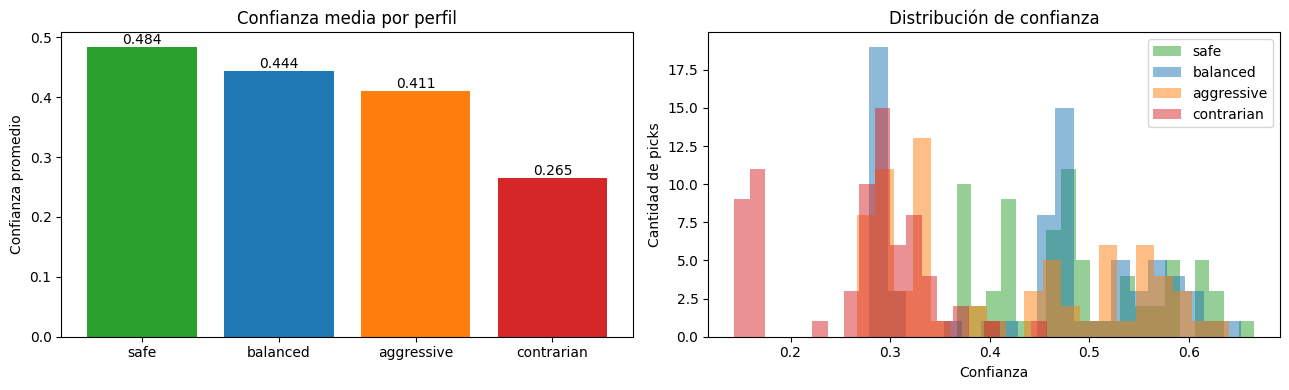

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

means = [sheets[p]['confidence'].mean() for p in PROFILES]
axes[0].bar(PROFILES, means, color=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'])
axes[0].set_ylabel('Confianza promedio')
axes[0].set_title('Confianza media por perfil')
for i, m in enumerate(means):
    axes[0].text(i, m + 0.005, f'{m:.3f}', ha='center')

for p, c in zip(PROFILES, ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728']):
    axes[1].hist(sheets[p]['confidence'], bins=20, alpha=0.5, label=p, color=c)
axes[1].set_xlabel('Confianza')
axes[1].set_ylabel('Cantidad de picks')
axes[1].set_title('Distribución de confianza')
axes[1].legend()

plt.tight_layout()
plt.show()

## Probabilidades de clasificación a octavos

In [5]:
qual = pd.read_csv(OUTPUTS / 'simulations' / 'tournament_probabilities.csv')
print(f'Total equipos: {len(qual)}')
print()
print('Top 20 con mayor prob de clasificación:')
print(qual.head(20).to_string(index=False))
print()
print('Bottom 10:')
print(qual.tail(10).to_string(index=False))

Total equipos: 48

Top 20 con mayor prob de clasificación:
              team  qualification_prob
          Paraguay              0.9775
          Congo DR              0.9345
            Panama              0.9325
          Scotland              0.9295
Cape Verde Islands              0.9010
           Czechia              0.8970
Bosnia-Herzegovina              0.8960
             Haiti              0.8895
              Iraq              0.8840
       New Zealand              0.8765
            Jordan              0.8545
           Ecuador              0.8510
            Norway              0.8510
           Austria              0.8450
      Saudi Arabia              0.8310
            Sweden              0.8265
           Curaçao              0.8180
             Ghana              0.7985
           Tunisia              0.7515
            Turkey              0.7280

Bottom 10:
     team  qualification_prob
    Japan              0.4635
   France              0.4480
  Germany           

## Favoritos al título

Total equipos con prob > 0: 45
Suma de probabilidades: 1.0000 (debe ≈ 1.0)

              team  championship_prob
          Paraguay             0.1835
            Panama             0.0930
Cape Verde Islands             0.0840
          Congo DR             0.0695
           Czechia             0.0590
Bosnia-Herzegovina             0.0540
          Scotland             0.0425
      Saudi Arabia             0.0370
              Iraq             0.0340
             Ghana             0.0300
           Ecuador             0.0295
            Norway             0.0290
           Curaçao             0.0240
            Turkey             0.0185
            Jordan             0.0185
            Sweden             0.0180
       New Zealand             0.0145
           Austria             0.0145
           Tunisia             0.0135
           Croatia             0.0125


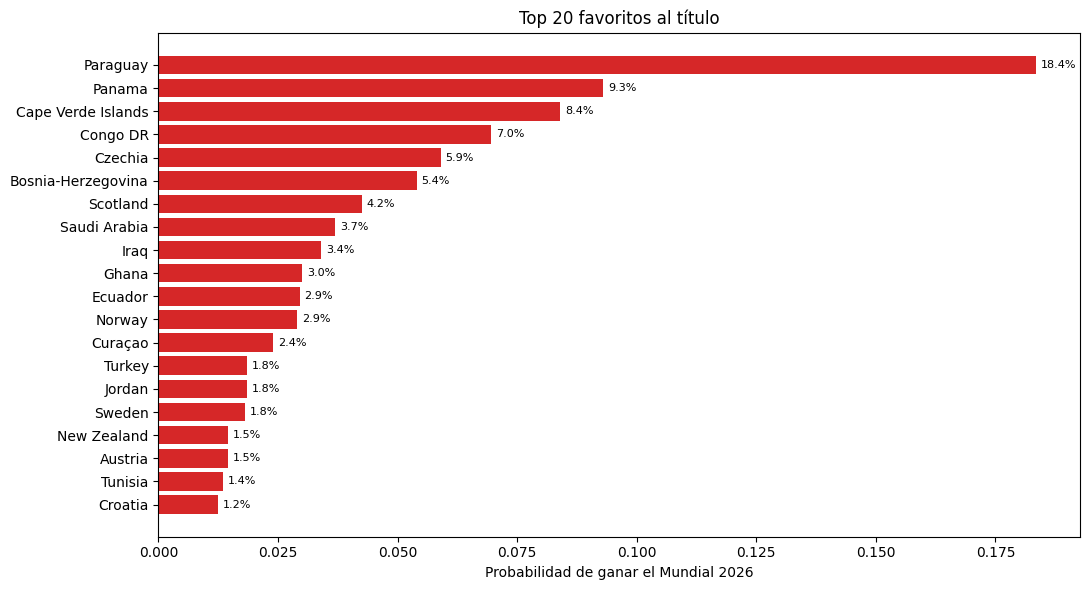

In [6]:
champ = pd.read_csv(OUTPUTS / 'simulations' / 'championship_probabilities.csv')
print(f'Total equipos con prob > 0: {(champ["championship_prob"] > 0).sum()}')
print(f'Suma de probabilidades: {champ["championship_prob"].sum():.4f} (debe ≈ 1.0)')
print()
top20 = champ.head(20)
print(top20.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top20['team'][::-1], top20['championship_prob'][::-1], color='#d62728')
ax.set_xlabel('Probabilidad de ganar el Mundial 2026')
ax.set_title('Top 20 favoritos al título')
for i, v in enumerate(top20['championship_prob'][::-1]):
    ax.text(v + 0.001, i, f'{v*100:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## Probabilidad de llegar a cada ronda (top 15)

Top 15 favoritos - prob de llegar a cada ronda:
                    Octavos
team                       
Paraguay               97.8
Panama                 93.2
Cape Verde Islands     90.1
Congo DR               93.4
Czechia                89.7
Bosnia-Herzegovina     89.6
Scotland               93.0
Saudi Arabia           83.1
Iraq                   88.4
Ghana                  79.8
Ecuador                85.1
Norway                 85.1
Curaçao                81.8
Turkey                 72.8
Jordan                 85.4


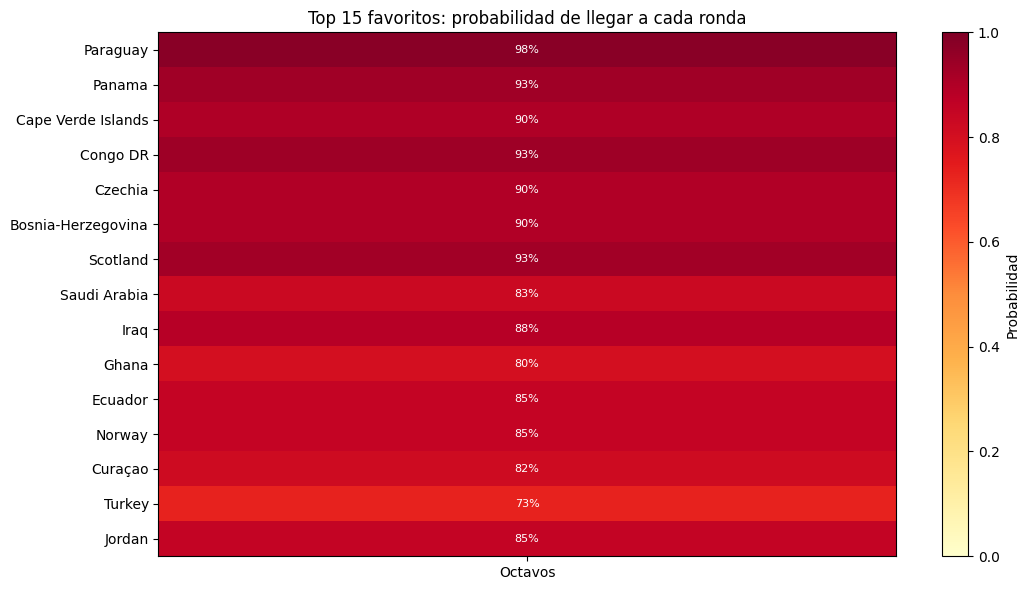

In [7]:
rounds = pd.read_csv(OUTPUTS / 'simulations' / 'round_reached_probabilities.csv')

STAGE_ORDER = ['r32', 'r16', 'qf', 'sf', 'final', 'champion']
STAGE_LABELS = {'r32': 'Octavos', 'r16': '8vos', 'qf': 'Cuartos', 'sf': 'Semis', 'final': 'Final', 'champion': 'Campeón'}

pivot = rounds.pivot_table(index='team', columns='stage', values='prob', aggfunc='max').fillna(0)
pivot = pivot.reindex(columns=[c for c in STAGE_ORDER if c in pivot.columns])
pivot.columns = [STAGE_LABELS.get(c, c) for c in pivot.columns]

top_teams = champ.head(15)['team'].tolist()
pivot_top = pivot.loc[[t for t in top_teams if t in pivot.index]]
print('Top 15 favoritos - prob de llegar a cada ronda:')
print((pivot_top * 100).round(1).to_string())

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(pivot_top.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(pivot_top.columns)))
ax.set_xticklabels(pivot_top.columns)
ax.set_yticks(range(len(pivot_top.index)))
ax.set_yticklabels(pivot_top.index)
for i in range(len(pivot_top.index)):
    for j in range(len(pivot_top.columns)):
        v = pivot_top.values[i, j]
        if v > 0.01:
            ax.text(j, i, f'{v*100:.0f}%', ha='center', va='center', fontsize=8, color='black' if v < 0.5 else 'white')
fig.colorbar(im, label='Probabilidad')
ax.set_title('Top 15 favoritos: probabilidad de llegar a cada ronda')
plt.tight_layout()
plt.show()

## Distribución de los caminos del bracket (campeones más frecuentes)

In [8]:
paths = pd.read_csv(OUTPUTS / 'simulations' / 'bracket_paths.csv')
print(f'Total simulaciones: {len(paths)}')
print()
print('Combinaciones campeón / subcampeón más frecuentes (top 15):')
top_finals = paths.groupby(['champion', 'runner_up']).size().sort_values(ascending=False).head(15)
print(top_finals.to_string())

Total simulaciones: 2000

Combinaciones campeón / subcampeón más frecuentes (top 15):
champion            runner_up         
Paraguay            Panama                47
Panama              Paraguay              38
Paraguay            Congo DR              37
                    Ghana                 35
Congo DR            Paraguay              26
Cape Verde Islands  Panama                20
Paraguay            Czechia               18
                    Iraq                  18
Panama              Cape Verde Islands    17
Czechia             Paraguay              15
Congo DR            Cape Verde Islands    15
Paraguay            Uzbekistan            14
Congo DR            Saudi Arabia          14
                    Bosnia-Herzegovina    14
Panama              Ecuador               13


## Picks recomendados por perfil (preview)

In [9]:
for p in PROFILES:
    print('=' * 60)
    print(f'  PERFIL: {p.upper()}')
    print('=' * 60)
    cols = ['date', 'team_a', 'team_b', 'pick', 'confidence']
    cols = [c for c in cols if c in sheets[p].columns]
    print(sheets[p][cols].head(12).to_string(index=False))
    print()

  PERFIL: SAFE
      date        team_a             team_b pick  confidence
2026-06-11        Mexico       South Africa    H    0.542292
2026-06-12   South Korea            Czechia    H    0.607110
2026-06-12        Canada Bosnia-Herzegovina    H    0.607110
2026-06-13 United States           Paraguay    A    0.366782
2026-06-13         Qatar        Switzerland    A    0.619785
2026-06-13        Brazil            Morocco    H    0.542292
2026-06-14         Haiti           Scotland    A    0.483976
2026-06-14     Australia             Turkey    H    0.469338
2026-06-14       Germany            Curaçao    H    0.479654
2026-06-14   Netherlands              Japan    H    0.469875
2026-06-14   Ivory Coast            Ecuador    A    0.424011
2026-06-15         Spain Cape Verde Islands    H    0.631233

  PERFIL: BALANCED
      date        team_a             team_b pick  confidence
2026-06-11        Mexico       South Africa    H    0.525903
2026-06-12   South Korea            Czechia    H  